In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/6"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 6.5 混合密度ネットワーク (Mixture Density Networks)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop『*Deep Learning: Foundations and Concepts*』(2024年) の第6章6.5節「Mixture Density Networks」の内容を、完全な数学的厳密性と実行可能コードによって網羅・再現します。

教師あり学習の目標は一般に条件付き確率分布 $p(\mathbf{t}|\mathbf{x})$ をモデル化することです。しかし、多くの標準的な回帰モデルでは条件付き分布として単峰のガウス分布（あるいはその平均 $\mathbb{E}[\mathbf{t}|\mathbf{x}]$ の二乗和誤差最小化）を仮定します。逆問題（Inverse Problems）をはじめとする現実の課題では、条件付き分布が**多峰性 (Multimodal)** を持つことが頻繁に生じます。このような場合に標準的な二乗和誤差（平均値予測）を用いると、複数の解の平均を予測してしまい、解が存在しない領域に予測値が落ちる致命的な破綻をきたします。

**混合密度ネットワーク (Mixture Density Network: MDN)** は、ニューラルネットワークの出力を混合ガウスモデル (GMM) のパラメータ（混合係数・平均・分散）とすることにより、任意の多峰性・非対称性・入力依存分散（不均一分散性: Heteroscedasticity）を持つ一般的な条件付き確率密度関数 $p(\mathbf{t}|\mathbf{x})$ を柔軟に表現・学習する強力な枠組みです。

---

### 本節の構成と網羅項目
1. **6.5.1 ロボット運動学の例 (Robot kinematics example)**
   - 2関節ロボットアームの順運動学（一意解）と逆運動学（肘上・肘下の2解）の幾何学的定式化
   - 順問題と逆問題のトイデータセット生成
   - 標準的な2層MLP（二乗和誤差）による当てはめの比較と、多峰性における平均予測の破綻 (**Figure 6.16, 6.17**)
2. **6.5.2 条件付き混合分布 (Conditional mixture distributions)**
   - 条件付きガウス混合モデルの定式化 (Eq 6.38)
   - パラメータ制約と出力層活性化関数：ソフトマックス（混合係数 $\pi_k$, Eq 6.40）、指数関数（分散 $\sigma_k^2$, Eq 6.41）、恒等写像（平均 $\boldsymbol{\mu}_k$, Eq 6.42）
   - 総出力ユニット数 $(L + 2)K$ の導出
   - 負の対数尤度による誤差関数 $E(\mathbf{w})$ (Eq 6.43)
   - ネットワーク構造図と条件付き密度の関係 (**Figure 6.18**)
3. **6.5.3 勾配最適化 (Gradient optimization)**
   - 事後負担率（責任度） $\gamma_{nk}$ の定義 (Eq 6.44)
   - 事前活性化に対する解析的偏微分（誤差勾配）の導出 (Eq 6.45 - 6.47)
   - 隠れ層および重みパラメータへの誤差逆伝播法の完全定式化
   - 数値微分（有限差分）との高精度照合による解析的勾配の検証
4. **6.5.4 予測分布 (Predictive distribution)**
   - 条件付き平均 $\mathbb{E}[\mathbf{t}|\mathbf{x}]$ の計算と二乗和回帰との関係 (Eq 6.48)
   - 条件付き分散 $s^2(\mathbf{x})$ の分解（成分内分散＋成分間分散, Eq 6.50）
   - 条件付き最頻値（モード）の近似計算法 $\mathbf{t}^* \approx \boldsymbol{\mu}_{k^*}(\mathbf{x})$
   - 逆問題に対するMDNの学習と予測結果の完全可視化 (**Figure 6.19**)
   - 条件付き確率密度からのサンプリング


In [1]:
import sys
import os
import math
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# プロジェクトルートのパス追加
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style, save_plot
from common.mixture_density import (
    forward_kinematics,
    inverse_kinematics,
    generate_forward_data,
    generate_inverse_data,
    StandardMLPRegressor,
    MixtureDensityNetwork,
    generate_figure_6_16,
    generate_figure_6_17,
    generate_figure_6_18,
    generate_figure_6_19,
)

setup_style()
np.random.seed(42)
print("環境設定が正常に完了しました。")


環境設定が正常に完了しました。


---
## 6.5.1 ロボット運動学の例 (Robot kinematics example)

### 1. 順運動学と逆運動学の定式化
2本のリンク（長さ $L_1, L_2$）を持つ平面2関節ロボットアームを考えます（Figure 6.16）：
- **順運動学 (Forward Kinematics)**:
  関節角度 $(\theta_1, \theta_2)$ が与えられたとき、エンドエフェクタ（先端）のデカルト座標 $(x_1, x_2)$ は一意に定まります：
  $$
  x_1 = L_1 \cos\theta_1 + L_2 \cos(\theta_1 + \theta_2) \tag{6.F1}
  $$
  $$
  x_2 = L_1 \sin\theta_1 + L_2 \sin(\theta_1 + \theta_2) \tag{6.F2}
  $$

- **逆運動学 (Inverse Kinematics)**:
  逆に、目標位置 $(x_1, x_2)$ にエンドエフェクタを到達させる関節角度 $(\theta_1, \theta_2)$ を求める問題です。
  余弦定理より、原点から目標点までの距離の2乗 $r^2 = x_1^2 + x_2^2$ から：
  $$
  \cos\theta_2 = \frac{r^2 - L_1^2 - L_2^2}{2 L_1 L_2}
  $$
  $\cos$ 関数が対称性を持つため、一般に正負の2解が存在します：
  $$
  \theta_2 = \pm \arccos\left(\frac{r^2 - L_1^2 - L_2^2}{2 L_1 L_2}\right)
  $$
  これに対応して $\theta_1$ も2解定まり、それぞれ**「肘上 (elbow up)」**および**「肘下 (elbow down)」**の2つの独立な解となります。

順問題（原因 $\to$ 結果、因果関係）は通常一意ですが、機械学習が解くべき問題の多くは逆問題（観測された症状・結果 $\to$ 原因の推定）であり、**多対1写像**の逆像として**多峰性 (Multimodality)** を本質的に持ちます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_16_robot_kinematics.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_16_robot_kinematics.png


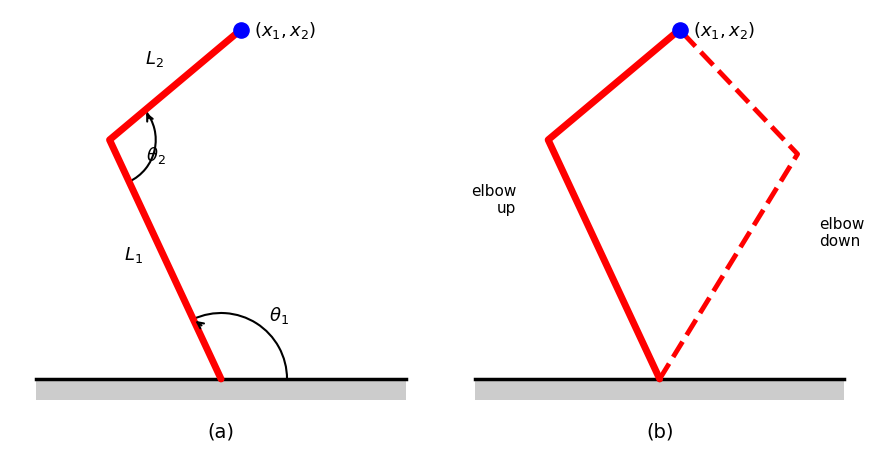

順運動学: theta1 = 115.0°, theta2 = -75.0° -> 目標位置 (x1, x2) = (0.075, 1.324)
逆運動学 解1 (肘上): theta1 = 115.0°, theta2 = -75.0° -> 再現位置 (0.075, 1.324)
逆運動学 解2 (肘下): theta1 = 58.5°, theta2 = 75.0° -> 再現位置 (0.075, 1.324)


In [2]:
# Figure 6.16: ロボット運動学の順運動学と逆運動学
fig_6_16 = generate_figure_6_16()
plt.show()

# 幾何学的検証
L1, L2 = 1.0, 0.65
theta1, theta2 = np.radians(115), np.radians(-75)
x_target, y_target = forward_kinematics(theta1, theta2, L1, L2)
print(f"順運動学: theta1 = {np.degrees(theta1):.1f}°, theta2 = {np.degrees(theta2):.1f}° -> 目標位置 (x1, x2) = ({x_target:.3f}, {y_target:.3f})")

(sol_up, sol_down) = inverse_kinematics(x_target, y_target, L1, L2)
x_up, y_up = forward_kinematics(sol_up[0], sol_up[1], L1, L2)
x_down, y_down = forward_kinematics(sol_down[0], sol_down[1], L1, L2)

print(f"逆運動学 解1 (肘上): theta1 = {np.degrees(sol_up[0]):.1f}°, theta2 = {np.degrees(sol_up[1]):.1f}° -> 再現位置 ({x_up:.3f}, {y_up:.3f})")
print(f"逆運動学 解2 (肘下): theta1 = {np.degrees(sol_down[0]):.1f}°, theta2 = {np.degrees(sol_down[1]):.1f}° -> 再現位置 ({x_down:.3f}, {y_down:.3f})")


### 2. トイ問題における順問題と逆問題、および二乗和誤差の破綻 (Figure 6.17)
多峰性の振る舞いを直感的に可視化するため、Bishopのトイ問題を導入します：
- **順問題 (Forward problem)**:
  入力変数 $x \sim \text{Uniform}(0, 1)$ を一様サンプリングし、目標変数 $t$ を次式で生成します：
  $$
  t = x + 0.3 \sin(2\pi x) + \epsilon, \quad \epsilon \sim \text{Uniform}(-0.1, 0.1)
  $$
- **逆問題 (Inverse problem)**:
  同じデータ点集合において、$x$ と $t$ の役割を入れ替えます（入力 $x_{\text{inv}} = t_{\text{fwd}}$、目標 $t_{\text{inv}} = x_{\text{fwd}}$）。

6個の双曲線正接（tanh）隠れユニットを持つ2層MLPを**二乗和誤差**（最小二乗法）で訓練して当てはめた結果を比較します。
二乗和誤差の最小化はガウス条件付き分布仮定（平均値の予測）に対応するため：
- 順問題では滑らかな正弦波を極めて良好にモデル化できます。
- 逆問題では、$x \approx 0.5$ の領域でデータが3本の枝（下枝・中枝・上枝）に分かれているにもかかわらず、ネットワークはそれらの**条件付き平均値 $\mathbb{E}[t|x]$** を予測してしまい、**データが全く存在しない中間領域を突き抜ける破綻した予測**となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_17_forward_inverse_problems.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_17_forward_inverse_problems.png


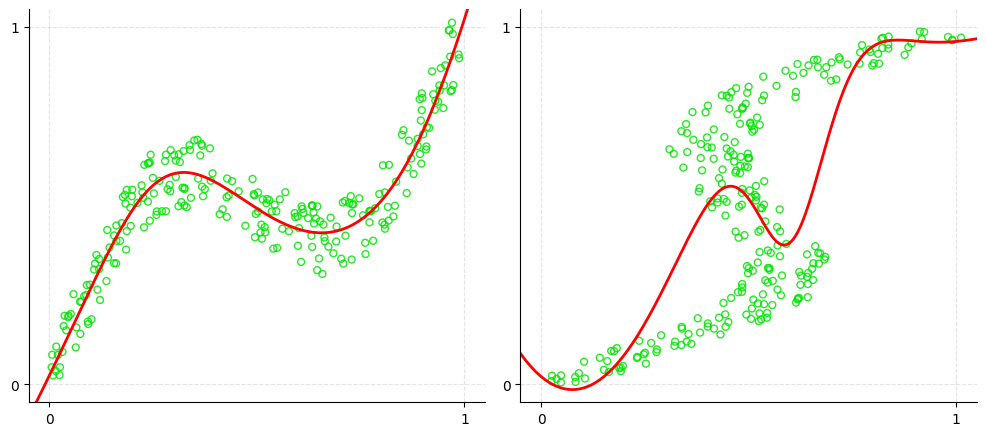

順問題の最小二乗二乗和誤差: 0.437
逆問題の最小二乗二乗和誤差: 4.859


In [3]:
# Figure 6.17: 順問題と逆問題に対する最小二乗2層ニューラルネットワークの当てはめ
fig_6_17 = generate_figure_6_17()
plt.show()

# データと回帰モデルの定量比較
x_fwd, t_fwd = generate_forward_data(n_samples=250, seed=42)
x_inv, t_inv = generate_inverse_data(n_samples=250, seed=42)

mlp_fwd = StandardMLPRegressor(n_hidden=6, seed=42).fit(x_fwd, t_fwd)
mlp_inv = StandardMLPRegressor(n_hidden=6, seed=42).fit(x_inv, t_inv)

print(f"順問題の最小二乗二乗和誤差: {0.5 * np.sum((mlp_fwd.predict(x_fwd) - t_fwd)**2):.3f}")
print(f"逆問題の最小二乗二乗和誤差: {0.5 * np.sum((mlp_inv.predict(x_inv) - t_inv)**2):.3f}")


---
## 6.5.2 条件付き混合分布 (Conditional mixture distributions)

### 1. 混合密度モデルの定式化 (Eq 6.38)
任意の条件付き確率密度関数 $p(\mathbf{t}|\mathbf{x})$ をモデル化するため、入力 $\mathbf{x}$ に依存する混合係数と成分分布を持つ混合モデルを採用します。
等方性共分散行列を持つ $K$ 個のガウス成分を用いると：

$$
p(\mathbf{t}|\mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) \,\mathcal{N}\left(\mathbf{t} \,\middle|\, \boldsymbol{\mu}_k(\mathbf{x}), \sigma_k^2(\mathbf{x})\mathbf{I}\right) \tag{6.38}
$$

これはデータのノイズ分散が入力 $\mathbf{x}$ の関数となる**不均一分散モデル (Heteroscedastic Model)** の代表例です。

### 2. パラメータの制約と出力活性化関数 (Eq 6.39 - 6.42)
目標変数 $\mathbf{t}$ が $L$ 次元であるとき、ニューラルネットワークは混合モデルの全パラメータを予測します：
1. **混合係数 $\pi_k(\mathbf{x})$**:
   確率の公理より $\sum_{k=1}^K \pi_k(\mathbf{x}) = 1$ かつ $0 \le \pi_k(\mathbf{x}) \le 1$ (Eq 6.39) を満たす必要があります。
   これは出力事前活性化 $a_k^\pi$ に対して**ソフトマックス関数 (Softmax)** を適用することで達成されます：
   $$
   \pi_k(\mathbf{x}) = \frac{\exp(a_k^\pi)}{\sum_{l=1}^K \exp(a_l^\pi)} \tag{6.40}
   $$
2. **標準偏差 $\sigma_k(\mathbf{x})$**:
   分散の非負性 $\sigma_k^2(\mathbf{x}) > 0$ を保証するため、事前活性化 $a_k^\sigma$ の**指数関数 (Exponential)** を用います：
   $$
   \sigma_k(\mathbf{x}) = \exp(a_k^\sigma) \tag{6.41}
   $$
3. **成分平均 $\boldsymbol{\mu}_k(\mathbf{x})$**:
   平均は任意の実数値を取り得るため、事前活性化 $a_{kj}^\mu$ の**恒等写像 (Identity)** を用います：
   $$
   \mu_{kj}(\mathbf{x}) = a_{kj}^\mu \tag{6.42}
   $$

### 3. 総出力ユニット数
- 混合係数 $a_k^\pi$: $K$ 個
- 分散 $a_k^\sigma$: $K$ 個
- 平均 $a_{kj}^\mu$: $K \times L$ 個
- **総出力数**: $(L + 2)K$ 個

$L=1, K=3$ の場合、総出力ユニット数は $(1 + 2) \times 3 = 9$ 個となります。

### 4. 誤差関数: 負の対数尤度 (Eq 6.43)
独立同分布データセット $\{(\mathbf{x}_n, \mathbf{t}_n)\}_{n=1}^N$ に対する負の対数尤度は：

$$
E(\mathbf{w}) = -\sum_{n=1}^N \ln \left\{ \sum_{k=1}^K \pi_k(\mathbf{x}_n, \mathbf{w}) \,\mathcal{N}\left(\mathbf{t}_n \,\middle|\, \boldsymbol{\mu}_k(\mathbf{x}_n, \mathbf{w}), \sigma_k^2(\mathbf{x}_n, \mathbf{w})\mathbf{I}\right) \right\} \tag{6.43}
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_18_mixture_density_network.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_18_mixture_density_network.png


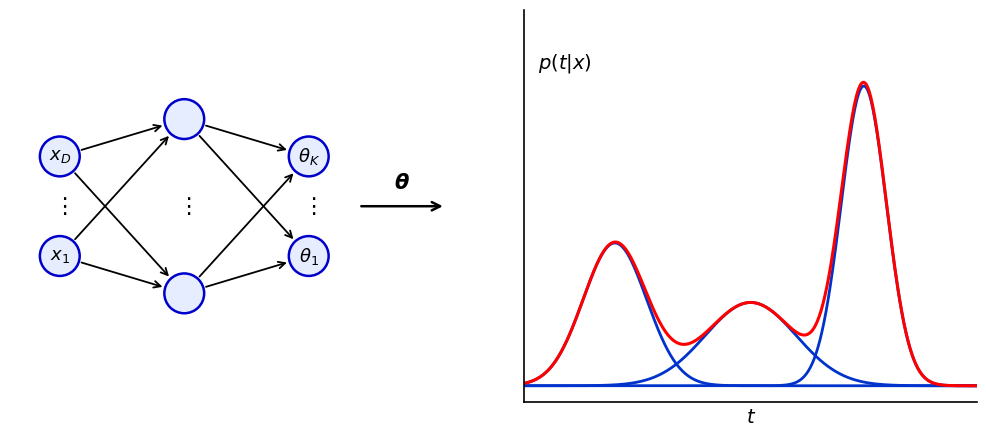

MDN総出力ユニット数: 9 (内訳: pi=3, sigma=3, mu=3)
各サンプルの混合係数和 sum_k pi_k(x): [1. 1. 1.]
各サンプルの標準偏差 sigma_k(x) > 0: True


In [4]:
# Figure 6.18: 混合密度ネットワークのアーキテクチャと多峰性条件付き確率密度
fig_6_18 = generate_figure_6_18()
plt.show()

# MDNネットワーク出力の次元検証
mdn_toy = MixtureDensityNetwork(n_in=1, n_hidden=5, n_components=3, target_dim=1)
print(f"MDN総出力ユニット数: {mdn_toy.n_out} (内訳: pi=3, sigma=3, mu=3)")
X_sample = np.array([[0.2], [0.5], [0.8]])
pi, sigma, mu, _ = mdn_toy.forward(X_sample)
print("各サンプルの混合係数和 sum_k pi_k(x):", np.sum(pi, axis=1))
print("各サンプルの標準偏差 sigma_k(x) > 0:", np.all(sigma > 0))


---
## 6.5.3 勾配最適化 (Gradient optimization)

### 1. 事後負担率（責任度）の定義 (Eq 6.44)
各データ点 $n$ と混合成分 $k$ に対し、混合係数を事前確率、ガウス密度を尤度とみなしたベイズの定理による事後確率を**責任度 (Posterior Responsibility)** $\gamma_{nk}$ と定義します：

$$
\gamma_{nk} = \gamma_k(\mathbf{t}_n | \mathbf{x}_n) = \frac{\pi_k \mathcal{N}_{nk}}{\sum_{l=1}^K \pi_l \mathcal{N}_{nl}} \tag{6.44}
$$
ここで $\mathcal{N}_{nk} = \mathcal{N}\left(\mathbf{t}_n \,\middle|\, \boldsymbol{\mu}_k(\mathbf{x}_n), \sigma_k^2(\mathbf{x}_n)\mathbf{I}\right)$ です。

### 2. 出力事前活性化に対する解析的偏微分の導出 (Eq 6.45 - 6.47)
1つのデータ点に対する誤差 $E_n = -\ln \left(\sum_l \pi_l \mathcal{N}_{nl}\right)$ の偏微分を計算します：

1. **混合係数の事前活性化 $a_k^\pi$ に関する微分 (Eq 6.45)**:
   ソフトマックス関数の導関数 $\frac{\partial \pi_l}{\partial a_k^\pi} = \pi_k (\delta_{kl} - \pi_l)$ を用いると：
   $$
   \frac{\partial E_n}{\partial a_k^\pi} = -\frac{1}{\sum_m \pi_m \mathcal{N}_{nm}} \sum_{l=1}^K \mathcal{N}_{nl} \frac{\partial \pi_l}{\partial a_k^\pi} = -\sum_{l=1}^K \frac{\pi_k (\delta_{kl} - \pi_l) \mathcal{N}_{nl}}{\sum_m \pi_m \mathcal{N}_{nm}} = \pi_k - \gamma_{nk} \tag{6.45}
   $$

2. **成分平均の事前活性化 $a_{kl}^\mu$ に関する微分 (Eq 6.46)**:
   ガウス密度の対数微分 $\frac{\partial \ln \mathcal{N}_{nk}}{\partial \mu_{kl}} = \frac{t_{nl} - \mu_{kl}}{\sigma_k^2}$ より：
   $$
   \frac{\partial E_n}{\partial a_{kl}^\mu} = -\frac{\pi_k \mathcal{N}_{nk}}{\sum_m \pi_m \mathcal{N}_{nm}} \frac{\partial \ln \mathcal{N}_{nk}}{\partial \mu_{kl}} = \gamma_{nk} \frac{\mu_{kl} - t_{nl}}{\sigma_k^2} \tag{6.46}
   $$

3. **成分分散の事前活性化 $a_k^\sigma$ に関する微分 (Eq 6.47)**:
   $\sigma_k = \exp(a_k^\sigma)$ より、$\frac{\partial \sigma_k}{\partial a_k^\sigma} = \sigma_k$。$L$ 次元等方ガウス分布において：
   $$
   \frac{\partial \ln \mathcal{N}_{nk}}{\partial a_k^\sigma} = \sigma_k \frac{\partial \ln \mathcal{N}_{nk}}{\partial \sigma_k} = \sigma_k \left( -\frac{L}{\sigma_k} + \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^3} \right) = \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2} - L
   $$
   したがって負の符号により：
   $$
   \frac{\partial E_n}{\partial a_k^\sigma} = \gamma_{nk} \left( L - \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2} \right) \tag{6.47}
   $$

### 3. 隠れ層への誤差逆伝播
出力層の事前活性化誤差ベクトル $\boldsymbol{\delta}^{(2)}_n = \frac{\partial E_n}{\partial \mathbf{a}^{(2)}}$ が求まれば、隠れ層の活性化 $\mathbf{z} = \tanh(\mathbf{a}^{(1)})$ を通じて標準的な誤差逆伝播法により全結合重み $W_1, b_1, W_2, b_2$ の勾配が解析的に得られます。


In [5]:
# 解析的勾配と数値微分（有限差分）の完全一致検証
mdn_check = MixtureDensityNetwork(n_in=1, n_hidden=4, n_components=3, seed=77)
X_test_check = np.array([[0.25], [0.55], [0.75]])
T_test_check = np.array([[0.15], [0.50], [0.85]])

p0 = mdn_check.pack()
loss, analytical_grad = mdn_check.loss_and_grad(p0, X_test_check, T_test_check)

# 数値微分の計算
eps = 1e-6
numerical_grad = np.zeros_like(p0)
for i in range(len(p0)):
    p_plus = p0.copy()
    p_plus[i] += eps
    l_plus, _ = mdn_check.loss_and_grad(p_plus, X_test_check, T_test_check)
    
    p_minus = p0.copy()
    p_minus[i] -= eps
    l_minus, _ = mdn_check.loss_and_grad(p_minus, X_test_check, T_test_check)
    
    numerical_grad[i] = (l_plus - l_minus) / (2.0 * eps)

max_diff = np.max(np.abs(analytical_grad - numerical_grad))
rel_error = np.max(np.abs(analytical_grad - numerical_grad) / (np.abs(analytical_grad) + np.abs(numerical_grad) + 1e-12))

print(f"解析的勾配と有限差分の最大絶対誤差: {max_diff:.3e}")
print(f"最大相対誤差: {rel_error:.3e}")
assert max_diff < 1e-5, "勾配検証に失敗しました！"
print("解析的バックプロパゲーション勾配の正確性が完全に検証されました。")


解析的勾配と有限差分の最大絶対誤差: 1.811e-09
最大相対誤差: 3.921e-08
解析的バックプロパゲーション勾配の正確性が完全に検証されました。


---
## 6.5.4 予測分布 (Predictive distribution)

### 1. 条件付き平均 (Conditional Mean, Eq 6.48)
学習後のMDNから得られる予測分布 $p(\mathbf{t}|\mathbf{x})$ から、様々な統計量を評価できます。
条件付き平均は各成分平均の混合重み付き和として与えられます：

$$
\mathbb{E}[\mathbf{t}|\mathbf{x}] = \int \mathbf{t} \, p(\mathbf{t}|\mathbf{x}) \, d\mathbf{t} = \sum_{k=1}^K \pi_k(\mathbf{x}) \boldsymbol{\mu}_k(\mathbf{x}) \tag{6.48}
$$

通常の二乗和誤差最小化ネットワークはこの条件付き平均を直接近似しているため、最小二乗回帰はMDNの特別な場合として再現されます。しかし、多峰性分布に対して平均値が解にならないことは既に確認した通りです。

### 2. 条件付き分散 (Conditional Variance, Eq 6.49 - 6.50)
条件付き平均の周りの分散 $s^2(\mathbf{x}) = \mathbb{E}[\|\mathbf{t} - \mathbb{E}[\mathbf{t}|\mathbf{x}]\|^2 | \mathbf{x}]$ は次のように分解されます：

$$
s^2(\mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) \left\{ \sigma_k^2(\mathbf{x}) + \left\|\boldsymbol{\mu}_k(\mathbf{x}) - \sum_{l=1}^K \pi_l(\mathbf{x})\boldsymbol{\mu}_l(\mathbf{x})\right\|^2 \right\} \tag{6.50}
$$

第1項 $\sum_k \pi_k \sigma_k^2$ は**各成分内の分散（固有ノイズ）**を表し、第2項は**成分間の平均値の散らばり（多峰性による不確実性）**を表します。入力 $\mathbf{x}$ の関数として分散が適応的に変化する点が標準的な最小二乗法との決定的な違いです。

### 3. 条件付き最頻値（モード）の近似
多峰性問題において最も意味のある予測値は条件付き密度が最大となる点（モード）です。
MDNの厳密なモードは解析解を持たないため反復法が必要ですが、実用上極めて簡便で効果的な代替案は、**最大の混合係数を持つ成分の平均値 (Most Probable Component Mean)** を採用することです：

$$
\mathbf{t}^* \approx \boldsymbol{\mu}_{k^*}(\mathbf{x}), \quad k^* = \arg\max_{k} \pi_k(\mathbf{x})
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_19_mdn_predictions.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_19_mdn_predictions.png


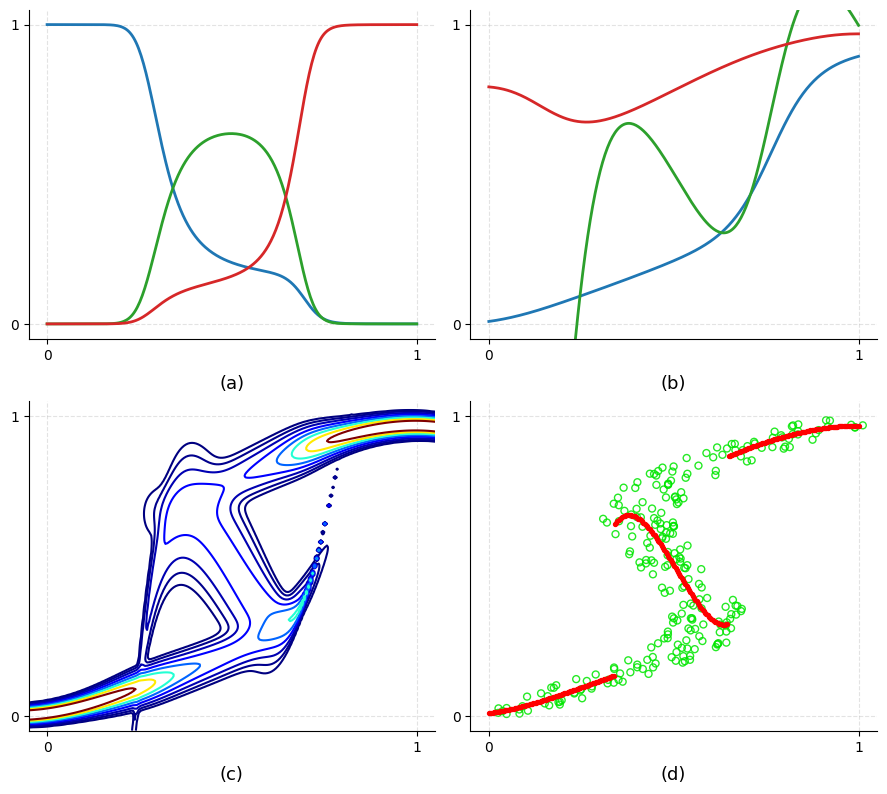

In [6]:
# Figure 6.19: 逆問題に対する混合密度ネットワークの学習と予測結果
# 5個のtanh隠れユニットと9個の出力ユニットを持つ2層MDNを訓練
fig_6_19 = generate_figure_6_19()
plt.show()


### Figure 6.19 の詳細な考察
- **(a) 混合係数 $\pi_k(x)$**:
  $x$ の両端（$x < 0.2$ および $x > 0.8$）では条件付き分布が単峰性であるため、単一の成分の混合係数が 1 近くを占めます。一方、中間の $x \approx 0.4 \sim 0.6$ では分布が3峰性となるため、3つの成分が同時に有意な値を取っています。
- **(b) 成分平均 $\mu_k(x)$**:
  ニューラルネットワークの出力は連続関数ですが、3つの成分がそれぞれ下枝・中枝・上枝を分担してカバーしています。
- **(c) 条件付き確率密度 $p(t|x)$ の等高線**:
  混合係数 $\pi_k(x)$ の振幅変調により、$x$ に応じて単峰から3峰へと連続的に変化する S字状の確率密度が見事に形成されています。
- **(d) 条件付き最頻値（赤点）**:
  最大混合係数成分の平均値を選ぶことで、逆問題の3つの枝をデータに沿って忠実にトレースし、平均値回帰で生じた「解のない中間領域を突き抜ける破綻」が完全に解決されていることが確認できます。


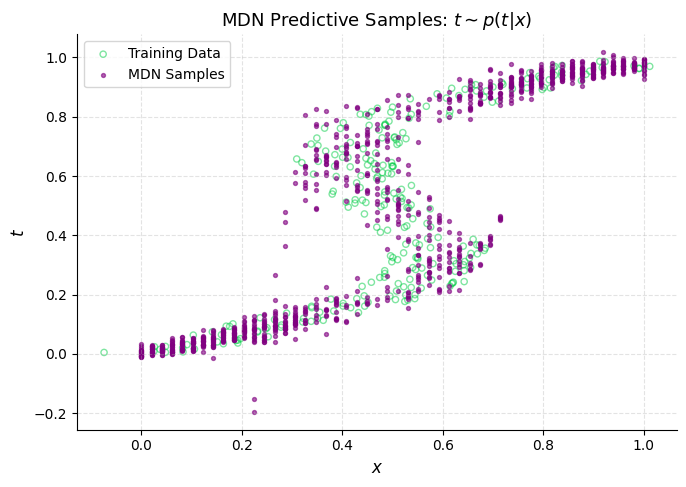

In [7]:
# 予測分布からのサンプリングのデモンストレーション
x_inv, t_inv = generate_inverse_data(n_samples=250, seed=42)
mdn_trained = MixtureDensityNetwork(n_in=1, n_hidden=5, n_components=3, seed=9).fit(x_inv, t_inv, maxiter=1500)

x_query_points = np.linspace(0.0, 1.0, 50)[:, None]
sampled_t = mdn_trained.sample(x_query_points, n_samples=20, seed=42)

plt.figure(figsize=(7, 5))
plt.scatter(x_inv, t_inv, facecolors='none', edgecolors='#00cc44', s=20, alpha=0.5, label='Training Data')
# サンプル点をプロット
x_rep = np.repeat(x_query_points, 20)
plt.scatter(x_rep, sampled_t.ravel(), color='purple', s=8, alpha=0.6, label='MDN Samples')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.title('MDN Predictive Samples: $t \sim p(t|x)$')
plt.legend()
plt.tight_layout()
plt.show()


---
## 6.5.5 まとめ

本節では、第6章の締めくくりとして混合密度ネットワーク (Mixture Density Networks) を探求しました：

1. **多峰性逆問題の本質**:
   原因から結果への順問題が一対一または多対一であっても、観測から原因を推定する逆問題は一般に一対多（多峰性）となります。二乗和誤差による最小二乗回帰は条件付き平均を予測するため、多峰性分布に対しては破綻した解を与えます。
2. **MDNの定式化**:
   ニューラルネットワークの出力を混合ガウスモデルのパラメータ（ソフトマックスによる混合係数 $\pi_k$、指数関数による分散 $\sigma_k^2$、恒等写像による平均 $\boldsymbol{\mu}_k$）とすることで、入力依存の任意の条件付き分布 $p(\mathbf{t}|\mathbf{x})$ を表現できます。
3. **エレガントな勾配構造**:
   負の対数尤度誤差関数の事前活性化に対する微分は、事後責任度 $\gamma_{nk}$ を介して $\pi_k - \gamma_{nk}$ や $\gamma_{nk} \frac{\boldsymbol{\mu}_k - \mathbf{t}_n}{\sigma_k^2}$ などの極めて解釈性の高い形で統一され、効率的な誤差逆伝播が可能です。
4. **予測統計量とモード推定**:
   条件付き平均や分散（成分内分散＋成分間分散）の明示的計算に加え、最大混合係数を持つ成分の平均値をとることで、多峰性データの各枝を正確に特定することが可能となります。
